# NAVYA — Model Training

This notebook uses a deterministic woman-wise 800/100/100 split, fits all requested regressors through leakage-safe pipelines, and selects by validation MAE.

## 1. Imports, feature contract, and group split

Multiple windows belong to the same simulated woman. Splitting by woman prevents information from the same individual's longitudinal pattern appearing in both training and evaluation sets. Assertions print evidence that no woman can occur in more than one partition. MAE is the primary metric because it expresses prediction error directly in days.

In [2]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

ROOT = Path.cwd().resolve()
ROOT = ROOT if (ROOT / "data").exists() else ROOT.parent
FEATURES = [
    "age_years",
    "menarche_age",
    "height_cm",
    "weight_kg",
    "bmi",
    "sleep_hours",
    "stress_level",
    "exercise_frequency",
    "uses_medication_or_contraceptive",
    "prev_cycle_1",
    "prev_cycle_2",
    "prev_cycle_3",
    "avg_previous_cycle_length",
    "std_previous_cycle_length",
    "prev_period_1",
    "prev_period_2",
    "prev_period_3",
    "avg_previous_period_length",
]
df = pd.read_csv(ROOT / "processed_data" / "model_ready_dataset.csv")
rng = np.random.RandomState(42)
women = rng.permutation(np.sort(df.woman_id.unique()))
assert len(women) == 1000
train_w, val_w, test_w = women[:800], women[800:900], women[900:]
for name, a, b in [
    ("train ∩ validation", train_w, val_w),
    ("train ∩ test", train_w, test_w),
    ("validation ∩ test", val_w, test_w),
]:
    print(name, len(set(a) & set(b)))
assert (
    not (set(train_w) & set(val_w))
    and not (set(train_w) & set(test_w))
    and not (set(val_w) & set(test_w))
)
train = df[df.woman_id.isin(train_w)]
val = df[df.woman_id.isin(val_w)]
test = df[df.woman_id.isin(test_w)]
print("Rows (train/val/test):", len(train), len(val), len(test))
X_train, y_train = train[FEATURES], train.next_cycle_length_days
X_val, y_val = val[FEATURES], val.next_cycle_length_days

train ∩ validation 0
train ∩ test 0
validation ∩ test 0
Rows (train/val/test): 16000 2000 2000


## 2. Define the requested pipelines

Each pipeline fits its median imputer only on training rows. Linear Regression and SVR also scale after imputation; tree/boosting models do not require scaling. Exactly six requested regressors are compared.

In [3]:
def scaled(model):
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model),
        ]
    )


def tree(model):
    return Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", model)])


models = {
    "LinearRegression": scaled(LinearRegression()),
    "RandomForestRegressor": tree(
        RandomForestRegressor(n_estimators=250, random_state=42, n_jobs=-1)
    ),
    "SVR": scaled(SVR(C=1.0, epsilon=0.1)),
    "GradientBoostingRegressor": tree(GradientBoostingRegressor(random_state=42)),
    "XGBRegressor": tree(
        XGBRegressor(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
        )
    ),
    "HistGradientBoostingRegressor": tree(
        HistGradientBoostingRegressor(random_state=42)
    ),
}
REQUIRED_MODELS = [
    "XGBRegressor", "GradientBoostingRegressor", "HistGradientBoostingRegressor",
    "LinearRegression", "RandomForestRegressor", "SVR",
]
assert set(models) == set(REQUIRED_MODELS), "Only the six approved models may be trained."
print("Models:", list(models))

Models: ['LinearRegression', 'DecisionTreeRegressor', 'RandomForestRegressor', 'KNeighborsRegressor', 'SVR', 'GradientBoostingRegressor', 'XGBRegressor', 'HistGradientBoostingRegressor']


## 3. Fit and score validation predictions

MAE is the selection metric. MSE, RMSE, and R² are reported too; the same validation women are used for the previous-three-cycle mean baseline. The baseline tests whether machine learning provides value beyond simply averaging the user's previous three cycles.

In [4]:
def score(y, p):
    return {
        "MAE": mean_absolute_error(y, p),
        "MSE": mean_squared_error(y, p),
        "RMSE": mean_squared_error(y, p) ** 0.5,
        "R2": r2_score(y, p),
    }


rows = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    rows.append({"model": name, **score(y_val, pipe.predict(X_val))})
baseline = val[["prev_cycle_1", "prev_cycle_2", "prev_cycle_3"]].mean(axis=1)
rows.append({"model": "Previous-3 mean baseline", **score(y_val, baseline)})
comparison = pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)
display(comparison.round(4))
print(
    "Initial best ML model:",
    comparison[comparison.model.ne("Previous-3 mean baseline")].iloc[0].model,
)
out = ROOT / "results" / "metrics"
out.mkdir(parents=True, exist_ok=True)
comparison.to_csv(out / "initial_model_comparison.csv", index=False)

,model,MAE,MSE,RMSE,R2
0,XGBRegressor,1.0877,2.6563,1.6298,0.8338
1,GradientBoostingRegressor,1.0889,2.6506,1.6281,0.8342
2,HistGradientBoostingRegressor,1.0940,2.6981,1.6426,0.8312
3,LinearRegression,1.1174,2.8040,1.6745,0.8246
4,Previous-3 mean baseline,1.1260,2.9110,1.7062,0.8179
5,RandomForestRegressor,1.1760,3.0146,1.7363,0.8114
6,SVR,1.1973,3.0011,1.7324,0.8122
7,KNeighborsRegressor,1.3507,3.5103,1.8736,0.7804
8,DecisionTreeRegressor,1.8815,8.3995,2.8982,0.4745


Initial best ML model: XGBRegressor


## 4. Validation comparison plots

These charts make the MAE-first decision transparent and retain the baseline as a first-class comparator.

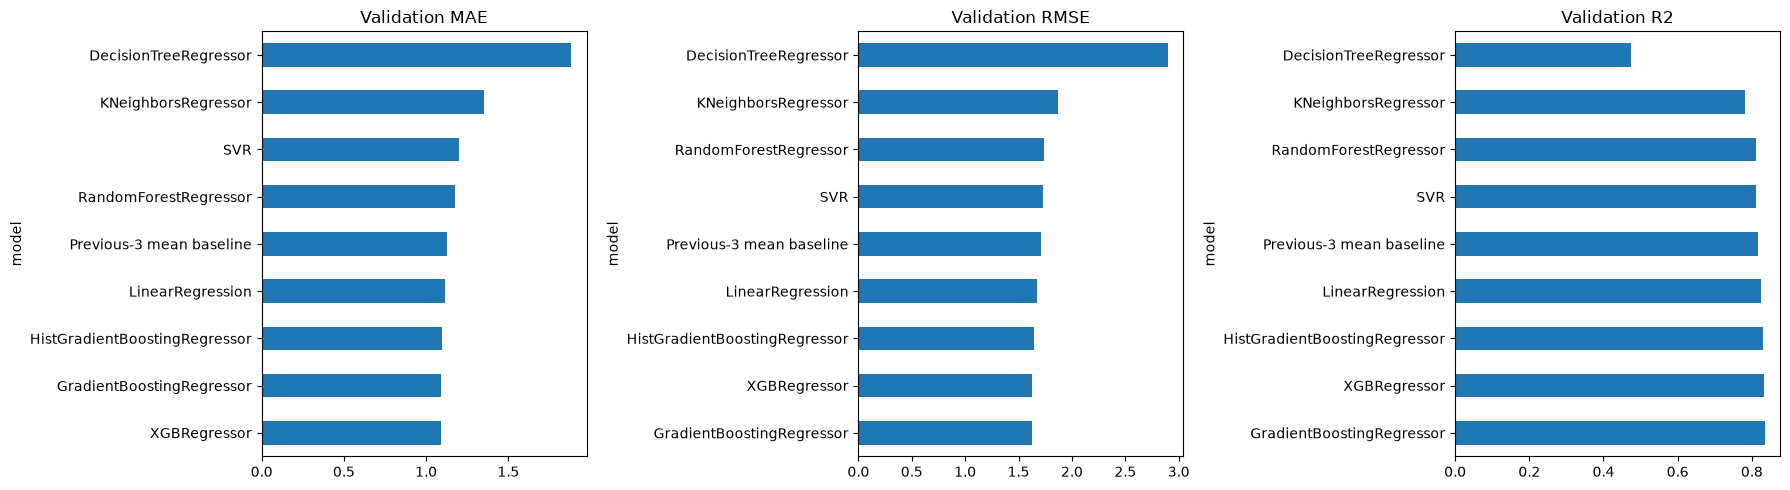

In [5]:
plots = ROOT / "results" / "plots"
plots.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for a, metric in zip(ax, ["MAE", "RMSE", "R2"]):
    comparison.sort_values(metric, ascending=(metric != "R2")).plot.barh(
        x="model", y=metric, legend=False, ax=a, title=f"Validation {metric}"
    )
plt.tight_layout()
plt.savefig(plots / "initial_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Best initial-model prediction diagnostic

The validation scatter and error histogram make the best initial model's calibration and error shape visible, rather than relying only on the comparison table.

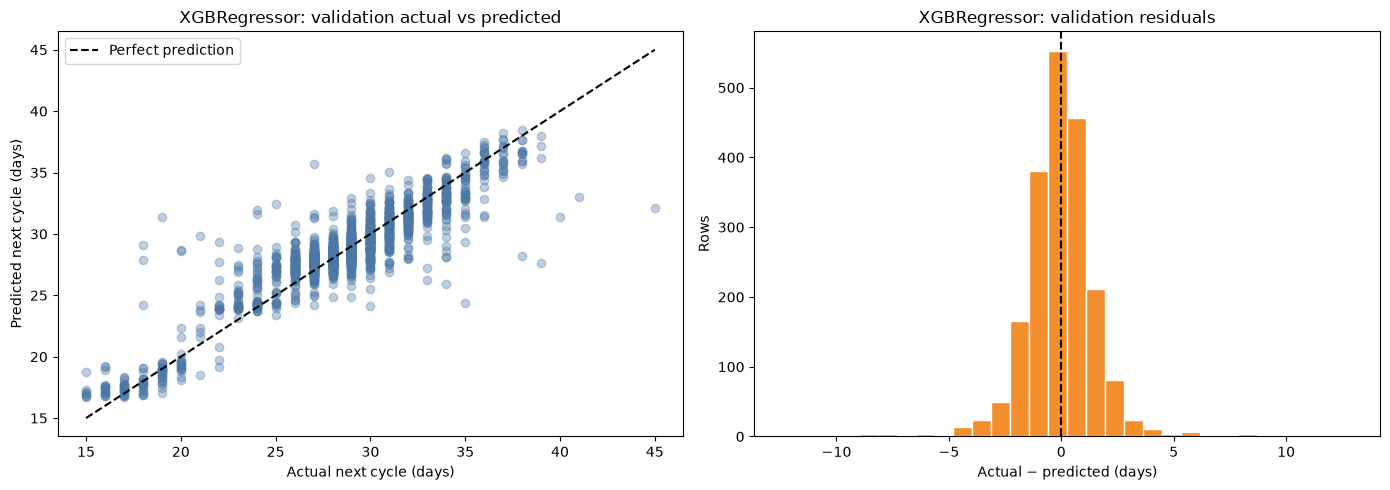

In [6]:
best_initial_name = comparison.loc[
    comparison["model"].ne("Previous-3 mean baseline"), "model"
].iloc[0]
best_initial_prediction = models[best_initial_name].predict(X_val)
initial_residual = y_val.to_numpy() - best_initial_prediction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_val, best_initial_prediction, alpha=0.35, color="#4C78A8")
limits = [
    min(y_val.min(), best_initial_prediction.min()),
    max(y_val.max(), best_initial_prediction.max()),
]
axes[0].plot(limits, limits, "k--", label="Perfect prediction")
axes[0].set(
    title=f"{best_initial_name}: validation actual vs predicted",
    xlabel="Actual next cycle (days)",
    ylabel="Predicted next cycle (days)",
)
axes[0].legend()
axes[1].hist(initial_residual, bins=30, color="#F28E2B", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(
    title=f"{best_initial_name}: validation residuals",
    xlabel="Actual − predicted (days)",
    ylabel="Rows",
)
plt.tight_layout()
plt.show()

## Observation

The first ML model in the sorted table is the initial best model. Notebook 05 tunes promising candidates without viewing the test women.